# 39 - Born-fraction nodes (s = 0.25) across κ

nb38 recommended `accdm_q_log_share = 0.25` from the chain settings (κ = 12.1, a_t = 0.133). This repeats
nb33's κ sweep with it: a_t = 0.09, m = 10¹¹ GeV, f_acc = 0.01, κ from 2 to 290, ΛCDM best fit of
`connect/Lite_lin/11`. nb33 found the even ln a grid with 51 bins stable only up to κ = 30, because births
squeeze into Δln a ≈ 9.2/κ around a_t and fewer nodes land there; s < 1 places nodes by born fraction, so the
window should stay resolved at any κ.

- **Even grid (s = 1):** nb33's runs, read from `33_cache.pkl` (reproduced by the current build to ≲ 3e-6 in the
  spectra).
- **s = 0.25:** 51, 101, 201 and 401 bins, and the 50/decade default count.
- **Verdict:** nb33's. Δχ² < 0.1 and max |ΔP_cb/P_cb| < 1e-3 against the even-grid 801-bin reference.
  At large κ that reference is itself unconverged (`u` in nb33), so every setting is also compared with s = 0.25
  at 401 bins, and the two references with each other.

Runtime about 20 min (70 new runs); cached in `39_cache.pkl`.

In [1]:
import json
import multiprocessing as mp
import pickle
import queue
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from classy import Class

import figkit as fk

fk.use('quick')


def find_root(start=None):
    start = Path.cwd() if start is None else start
    for d in [start, *start.parents]:
        if (d/'chains'/'fixed_masses').is_dir():
            return d
    raise FileNotFoundError('no chains/fixed_masses above {}'.format(start))


def read_bestfit(path):
    with open(path) as fh:
        names = [s.strip() for s in fh.readline().lstrip('#').split(',')]
        values = [float(v) for v in fh.readline().split()]
    return dict(zip(names, values))


BF = read_bestfit(find_root()/'chains'/'fixed_masses'/'connect'/'Lite_lin'/'11'/'11_lin.bestfit')
LCDM = {k: BF[k] for k in ('omega_b', 'omega_cdm', 'H0', 'ln10^{10}A_s', 'n_s', 'tau_reio')}

A_T = 0.09
F_ACC = 1e-2
F_NULL = 1e-6                     # signal reference; accDM needs f_acc > 0
KAPPAS = [2, 3, 5, 8, 12, 20, 30, 50, 75, 100, 150, 200, 250, 290
          #, 294, 295, 300, 350, 400, 500, 600
          ]
K_OVERFLOW = np.log(np.finfo(float).max)/np.log(1/A_T)    # (1/a_t)^kappa is inf above this

# connect/Lite_lin/11 settings with a_t = 0.09, strategy 5 and no DE sink; kappa and precision are set per run
SETTINGS = {'N_ncdm': 2, 'N_ur': 2.0308,
            'm_ncdm': '0.06, 0.1', 'deg_ncdm': '1, 1', 'T_ncdm': '0.71611, 1.0',
            'm_acc_in_GeV': 1e11, 'a_t_acc': A_T, 'vary_Gamma_acc': 'yes', 'acc_de_sink': 'no',
            'ncdm_quadrature_strategy': '0, 5', 'ncdm_fluid_approximation': 3,
            'gauge': 'synchronous', 'reionization_z_start_max': 80, 'evolver': 0,
            'output': 'mPk, lCl, tCl, pCl', 'P_k_max_1/Mpc': 1.0, 'lensing': 'yes', 'l_max_scalars': 2508}


def bins(n):
    return {'ncdm_N_momentum_bins': '15, {:d}'.format(n)}


# label: daughter precision parameters on top of SETTINGS
SETUPS = {'s5 51': bins(51),                     # production (params/1e11GeV.param)
          's5 101': bins(101),
          's5 201': bins(201),
          's5 401': bins(401),
          's5 801': bins(801),
          's5 50/dec': {},                       # default accdm_q_bins_per_decade
          's5 200/dec': {'accdm_q_bins_per_decade': 200},
          's5 51, q_tol 1e-9': {**bins(51), 'accdm_q_number_tol': 1e-9},
          's5 51, tol_pert 1e-6': {**bins(51), 'tol_perturbations_integration': 1e-6},
          's5 51, smooth births': {**bins(51), 'accdm_smooth_births': 1}
          }
PROD = 's5 51'
REF = 's5 801'
REF_CHECK = 's5 401'              # REF_CHECK vs REF estimates the reference error

print('LCDM best fit:', LCDM)
print('y = (a_q/a_t)^kappa overflows at a_q = 1 for kappa > {:.2f}'.format(K_OVERFLOW))
import pandas as pd

S = 0.25
NEW = {'s.25 51': {**bins(51), 'accdm_q_log_share': S},
       's.25 101': {**bins(101), 'accdm_q_log_share': S},
       's.25 201': {**bins(201), 'accdm_q_log_share': S},
       's.25 401': {**bins(401), 'accdm_q_log_share': S},
       's.25 50/dec': {'accdm_q_log_share': S}}
SETUPS.update(NEW)
OLD_LABS = ['s5 51', 's5 101', 's5 201', 's5 50/dec', 's5 401', 's5 801']
NEW_LABS = list(NEW)
LABS = OLD_LABS + NEW_LABS
ALT_REF = 's.25 401'

LCDM best fit: {'omega_b': 0.02256944, 'omega_cdm': 0.1175042, 'H0': 68.47743, 'ln10^{10}A_s': 3.056426, 'n_s': 0.972248, 'tau_reio': 0.06151263}
y = (a_q/a_t)^kappa overflows at a_q = 1 for kappa > 294.77


/opt/homebrew/Caskroom/miniforge/base/envs/accDM/lib/python3.12/site-packages/figkit/style.py:132: RuntimeWarning: text.usetex requested but latex, dvipng not found on PATH; falling back to matplotlib mathtext. Install TeX Live or MiKTeX (and dvipng) for identical output, or pass usetex=False to silence this.
  usetex = bool(usetex) and latex_available()


## 0. Nodes in the birth window

Nodes with 0.01 < F < 0.99, for the even grid and s = 0.25, from the same maps CLASS uses (a_min from
`accdm_q_number_tol` = 10⁻⁶; the born fraction is overflow-safe, as nb33's).

In [2]:
def born_fraction(a, kappa):
    with np.errstate(over='ignore'):
        return 1 - (1 - a**kappa)/(1 + (a/A_T)**kappa)


def a_min(kappa, eps=1e-6):
    lo, hi = np.log(1e-14), 0.0
    if born_fraction(np.exp(lo), kappa) >= eps:
        return np.exp(lo)
    for _ in range(200):
        mid = 0.5*(lo + hi)
        lo, hi = (mid, hi) if born_fraction(np.exp(mid), kappa) < eps else (lo, mid)
    return np.exp(lo)


def node_F(kappa, share, n=None, per_dec=50.0):
    am = a_min(kappa)
    if n is None:
        n = max(3, int(np.ceil(per_dec*np.log10(1/am))) + 1)
    n += n % 2 == 0
    lna = np.linspace(np.log(am), 0, 400001)
    F = born_fraction(np.exp(lna), kappa)
    Fm = born_fraction(am, kappa)
    u = share*(lna - lna[0])/(-lna[0]) + (1 - share)*(F - Fm)/(1 - Fm)
    return born_fraction(np.exp(np.interp(np.linspace(0, 1, n), u, lna)), kappa)


GRID = {'s5 51': (1.0, 51), 's5 201': (1.0, 201), 's5 801': (1.0, 801), 's5 50/dec': (1.0, None),
        's.25 51': (S, 51), 's.25 201': (S, 201), 's.25 50/dec': (S, None)}
rows = []
for k in KAPPAS:
    row = {'kappa': k, 'a_min': a_min(k)}
    for lab, (share, n) in GRID.items():
        F = node_F(k, share, n)
        row[lab] = '{}/{}'.format(len(F), int(np.sum((F > 0.01) & (F < 0.99))))
    rows.append(row)
print('q_size / nodes in 1-99% of births')
display(pd.DataFrame(rows).set_index('kappa'))

q_size / nodes in 1-99% of births


,a_min,s5 51,s5 201,s5 801,s5 50/dec,s.25 51,s.25 201,s.25 50/dec
kappa,,,,,,,,
2,0.000090,51/23,201/93,801/370,205/95,51/43,201/170,205/174
3,0.000900,51/22,201/87,801/347,155/67,51/43,201/169,155/129
5,0.005679,51/18,201/71,801/284,115/41,51/42,201/165,115/93
8,0.016005,51/14,201/56,801/223,91/25,51/41,201/161,91/73
12,0.028461,51/11,201/43,801/172,79/17,51/39,201/158,79/62
20,0.045107,51/7,201/30,801/118,69/10,51/38,201/155,69/52
30,0.056786,51/5,201/21,801/86,65/7,51/38,201/153,65/48
50,0.068272,51/3,201/14,801/55,61/4,51/37,201/151,61/45
75,0.074859,51/2,201/9,801/38,59/3,51/38,201/150,59/43


## 1. Runs

In [3]:
LMAX = 2500
ELL = np.arange(2, LMAX + 1)
KK = np.logspace(-4, np.log10(0.9), 300)                             # 1/Mpc, inside P_k_max
Z_BAO = np.array([0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330])  # DESI DR2 effective z
TIMEOUT = 900.0                                                      # s per run
CACHE = Path('39_cache.pkl')
cache = pickle.loads(CACHE.read_bytes()) if CACHE.exists() else {}


def params(kappa, lab, f_acc=F_ACC):
    return {**LCDM, **SETTINGS, **SETUPS[lab], 'kappa_acc': float(kappa), 'f_acc': f_acc}


def run(p):
    cosmo = Class()
    cosmo.set(p)
    try:
        cosmo.compute()
        cl = cosmo.lensed_cl(LMAX)
        out = {s: np.array(cl[s][2:]) for s in ('tt', 'ee', 'te', 'pp')}
        out['pk_cb'] = np.array([cosmo.pk_cb(k, 0.0) for k in KK])
        out['pk_m'] = np.array([cosmo.pk(k, 0.0) for k in KK])
        rd = cosmo.rs_drag()
        out['DM_rd'] = np.array([cosmo.angular_distance(z)*(1 + z) for z in Z_BAO])/rd
        out['DH_rd'] = np.array([1/cosmo.Hubble(z) for z in Z_BAO])/rd
        out.update(cosmo.get_current_derived_parameters(['100*theta_s', 'Omega_Lambda', 'sigma8']))
        out['sigma8_cb'] = cosmo.sigma8_cb()
        out['T_cmb'] = cosmo.T_cmb()
        bg = cosmo.get_background()
        out['Omega_acc'] = bg['(.)rho_ncdm[1]'][-1]/bg['(.)rho_crit'][-1]
    finally:
        cosmo.struct_cleanup()
        cosmo.empty()
    out['finite'] = bool(all(np.all(np.isfinite(v)) for v in out.values()))
    return out


def _child(p, q):
    try:
        q.put(run(p))
    except Exception as err:
        q.put({'error': '{}: {}'.format(type(err).__name__, err)})


def run_isolated(p):
    """run(p) in a forked child, so a crash or hang becomes an error entry."""
    ctx = mp.get_context('fork')
    q = ctx.Queue()
    proc = ctx.Process(target=_child, args=(p, q))
    t0 = time.time()
    proc.start()
    out = None
    while out is None:
        try:
            out = q.get(timeout=1.0)
        except queue.Empty:
            if not proc.is_alive():
                try:
                    out = q.get(timeout=2.0)
                except queue.Empty:
                    out = {'error': 'CLASS process died, exit code {}'.format(proc.exitcode)}
            elif time.time() - t0 > TIMEOUT:
                proc.kill()
                out = {'error': 'timeout after {:.0f} s'.format(TIMEOUT)}
    proc.join()
    out['sec'] = time.time() - t0
    return out


def cached_run(p):
    key = json.dumps(p, sort_keys=True)
    if key not in cache:
        cache[key] = run_isolated(p)
        CACHE.write_bytes(pickle.dumps(cache))
    return cache[key]


def ok(out):
    return 'error' not in out and out['finite']


def status(out, n=90):
    if 'error' in out:
        lines = [s.strip() for s in out['error'].splitlines() if s.strip()]
        return 'ERROR ' + (lines[-1] if lines else out['error'])[:n]
    return 'ok' if out['finite'] else 'NON-FINITE'


cache33 = pickle.loads(Path('33_cache.pkl').read_bytes())
_run_and_cache = cached_run


def cached_run(p):
    """nb33's run for these exact parameters, else a new cached run."""
    key = json.dumps(p, sort_keys=True)
    return cache33[key] if key in cache33 else _run_and_cache(p)

In [4]:
null = cached_run(params(5, PROD, F_NULL))
assert ok(null)
res = {}
for kappa in KAPPAS:
    for lab in LABS:
        res[(lab, kappa)] = out = cached_run(params(kappa, lab))
        if lab in NEW:
            print('kappa {:>4g}  {:<12s} {:5.0f} s  {}'.format(kappa, lab, out['sec'], status(out)), flush=True)

kappa    2  s.25 51          4 s  ok
kappa    2  s.25 101         8 s  ok
kappa    2  s.25 201        17 s  ok
kappa    2  s.25 401        40 s  ok
kappa    2  s.25 50/dec     20 s  ok
kappa    3  s.25 51          5 s  ok
kappa    3  s.25 101        10 s  ok
kappa    3  s.25 201        23 s  ok
kappa    3  s.25 401        61 s  ok
kappa    3  s.25 50/dec     20 s  ok
kappa    5  s.25 51          7 s  ok
kappa    5  s.25 101        14 s  ok
kappa    5  s.25 201        26 s  ok
kappa    5  s.25 401        58 s  ok
kappa    5  s.25 50/dec     14 s  ok
kappa    8  s.25 51          6 s  ok
kappa    8  s.25 101        13 s  ok
kappa    8  s.25 201        26 s  ok
kappa    8  s.25 401        64 s  ok
kappa    8  s.25 50/dec     12 s  ok
kappa   12  s.25 51          7 s  ok
kappa   12  s.25 101        13 s  ok
kappa   12  s.25 201        26 s  ok
kappa   12  s.25 401        58 s  ok
kappa   12  s.25 50/dec     10 s  ok
kappa   20  s.25 51          7 s  ok
kappa   20  s.25 101        13 s  ok
k

## 2. Verdict

nb33's symbols: `.` stable, `X` Δχ² > 0.1, `P` max |ΔP_cb/P_cb| > 1e-3, `E` error, `N` non-finite,
`u` reference unconverged (401 vs 801 above a tenth of the tolerances). First against the even-grid 801-bin
reference (nb33's), then against s = 0.25 at 401 bins.

In [5]:
FSKY = 0.6
ARCMIN = np.pi/(180*60)
BEAM, NOISE_T, NOISE_P = 7.0*ARCMIN, 33.0*ARCMIN, 70.0*ARCMIN    # beam in rad, noise in uK rad
SIGMA_LENS = 0.025
SIGMA_BAO = 0.01
L_LENS = (ELL >= 8) & (ELL <= 400)
DCHI2_TOL = 0.1
PK_TOL = 1e-3


def noise_cl(sigma, t_cmb):
    """Beam-deconvolved white noise in the dimensionless units of lensed_cl."""
    return (sigma/(t_cmb*1e6))**2*np.exp(ELL*(ELL + 1)*BEAM**2/(8*np.log(2)))


def chi2_parts(a, b):
    """Approximate delta chi2 of run a against run b, per probe."""
    tt = b['tt'] + noise_cl(NOISE_T, b['T_cmb'])
    ee = b['ee'] + noise_cl(NOISE_P, b['T_cmb'])
    te = b['te']
    d = np.array([a['tt'] - b['tt'], a['ee'] - b['ee'], a['te'] - b['te']]).T
    cov = np.array([[2*tt**2, 2*te**2, 2*tt*te],
                    [2*te**2, 2*ee**2, 2*ee*te],
                    [2*tt*te, 2*ee*te, tt*ee + te**2]])/((2*ELL + 1)*FSKY)
    x = np.linalg.solve(np.moveaxis(cov, 2, 0), d[:, :, None])[:, :, 0]
    cmb = float(np.sum(d*x))
    w = (2*ELL + 1)[L_LENS]
    a_lens = np.sum(w*(a['pp']/b['pp'] - 1)[L_LENS])/np.sum(w)
    lens = float((a_lens/SIGMA_LENS)**2)
    bao = float(np.sum((a['DM_rd']/b['DM_rd'] - 1)**2 + (a['DH_rd']/b['DH_rd'] - 1)**2)/SIGMA_BAO**2)
    return {'total': cmb + lens + bao, 'cmb': cmb, 'lens': lens, 'bao': bao}


def compare(lab, kappa, base=REF):
    a, b = res[(lab, kappa)], res[(base, kappa)]
    if not (ok(a) and ok(b)):
        return None
    return {'dchi2': chi2_parts(a, b)['total'],
            'dpk': float(np.max(np.abs(a['pk_cb']/b['pk_cb'] - 1))),
            'domega': a['Omega_acc']/b['Omega_acc'] - 1,
            'dsigma8': a['sigma8_cb']/b['sigma8_cb'] - 1}


def ref_converged(kappa):
    c = compare(REF_CHECK, kappa)
    return c is not None and c['dchi2'] < DCHI2_TOL/10 and c['dpk'] < PK_TOL/10


def verdict(lab, kappa):
    out = res[(lab, kappa)]
    if 'error' in out:
        return 'E'
    if not out['finite']:
        return 'N'
    if lab == REF:
        return '.' if ref_converged(kappa) else 'u'
    c = compare(lab, kappa)
    if c is None:
        return '?'
    if c['dchi2'] > DCHI2_TOL:
        return 'X'
    if c['dpk'] > PK_TOL:
        return 'P'
    return '.'


def kappa_max(lab):
    """Largest grid kappa up to which every kappa passes, and the first failure."""
    last = None
    for k in KAPPAS:
        v = verdict(lab, k)
        if v != '.':
            return last, (k, v)
        last = k
    return last, None


def verdict_vs(lab, kappa, base):
    out = res[(lab, kappa)]
    if 'error' in out:
        return 'E'
    if not out['finite']:
        return 'N'
    if lab == base:
        return '='
    c = compare(lab, kappa, base=base)
    if c is None:
        return '?'
    return 'X' if c['dchi2'] > DCHI2_TOL else ('P' if c['dpk'] > PK_TOL else '.')


def kappa_max_vs(lab, base):
    last = None
    for k in KAPPAS:
        v = verdict_vs(lab, k, base)
        if v not in '.=':
            return last, (k, v)
        last = k
    return last, None


for base in (REF, ALT_REF):
    print('\nagainst {}'.format(base))
    print('{:>6}'.format('kappa') + ''.join('{:>12}'.format(lab) for lab in LABS))
    for k in KAPPAS:
        print('{:>6g}'.format(k) + ''.join('{:>12}'.format(verdict(lab, k) if base == REF else verdict_vs(lab, k, base))
                                       for lab in LABS))
    for lab in LABS:
        km, fail = kappa_max_vs(lab, base)
        print('  {:<12s} stable up to kappa = {}{}'.format(lab, km, '' if fail is None else
                                                        '  (first failure: kappa {:g}, {})'.format(*fail)))


against s5 801
 kappa       s5 51      s5 101      s5 201   s5 50/dec      s5 401      s5 801     s.25 51    s.25 101    s.25 201    s.25 401 s.25 50/dec
     2           .           .           .           .           .           .           .           .           .           .           .
     3           .           .           .           .           .           u           .           .           .           .           .
     5           .           .           .           .           .           u           .           .           .           .           .
     8           .           .           .           .           .           u           .           .           .           .           .
    12           .           .           .           .           .           .           .           .           .           .           .
    20           .           .           .           .           .           .           .           .           .           .           .
    30     

,s5 51 vs s5 801,s.25 51 vs s5 801,s.25 51 vs s.25 401,s.25 101 vs s.25 401,s.25 201 vs s.25 401,s.25 50/dec vs s.25 401,s5 401 vs s5 801,s5 801 vs s.25 401,signal (801 vs null)
kappa,,,,,,,,,
2,4.3e-04,1.0e-04,1.0e-04,5.2e-05,8.0e-06,1.1e-05,2.3e-06,1.2e-06,5.6e+01
3,4.2e-02,1.0e-04,1.1e-04,8.8e-06,4.1e-02,3.8e-06,4.1e-02,1.6e-06,5.8e+01
5,4.4e-04,2.6e-05,2.3e-05,1.2e-06,9.7e-07,1.2e-06,4.1e-02,2.0e-07,5.9e+01
8,4.2e-02,4.1e-02,8.2e-05,4.1e-02,2.9e-08,3.0e-06,4.1e-02,4.1e-02,5.9e+01
12,4.2e-04,6.6e-05,6.5e-05,7.1e-07,2.1e-07,1.9e-06,1.4e-06,7.1e-08,5.9e+01
20,1.5e-03,1.5e-04,1.6e-04,4.1e-02,2.2e-07,4.1e-02,1.3e-07,8.4e-07,5.9e+01
30,7.0e-02,1.3e-03,4.3e-02,4.1e-02,4.1e-02,4.2e-02,4.9e-07,4.1e-02,5.9e+01
50,2.0e+00,8.0e-03,8.0e-03,4.3e-04,2.8e-06,2.4e-03,3.8e-07,1.6e-07,5.9e+01
75,8.5e+00,3.5e-02,3.5e-02,2.1e-04,2.1e-05,4.6e-02,2.8e-07,3.4e-07,5.9e+01


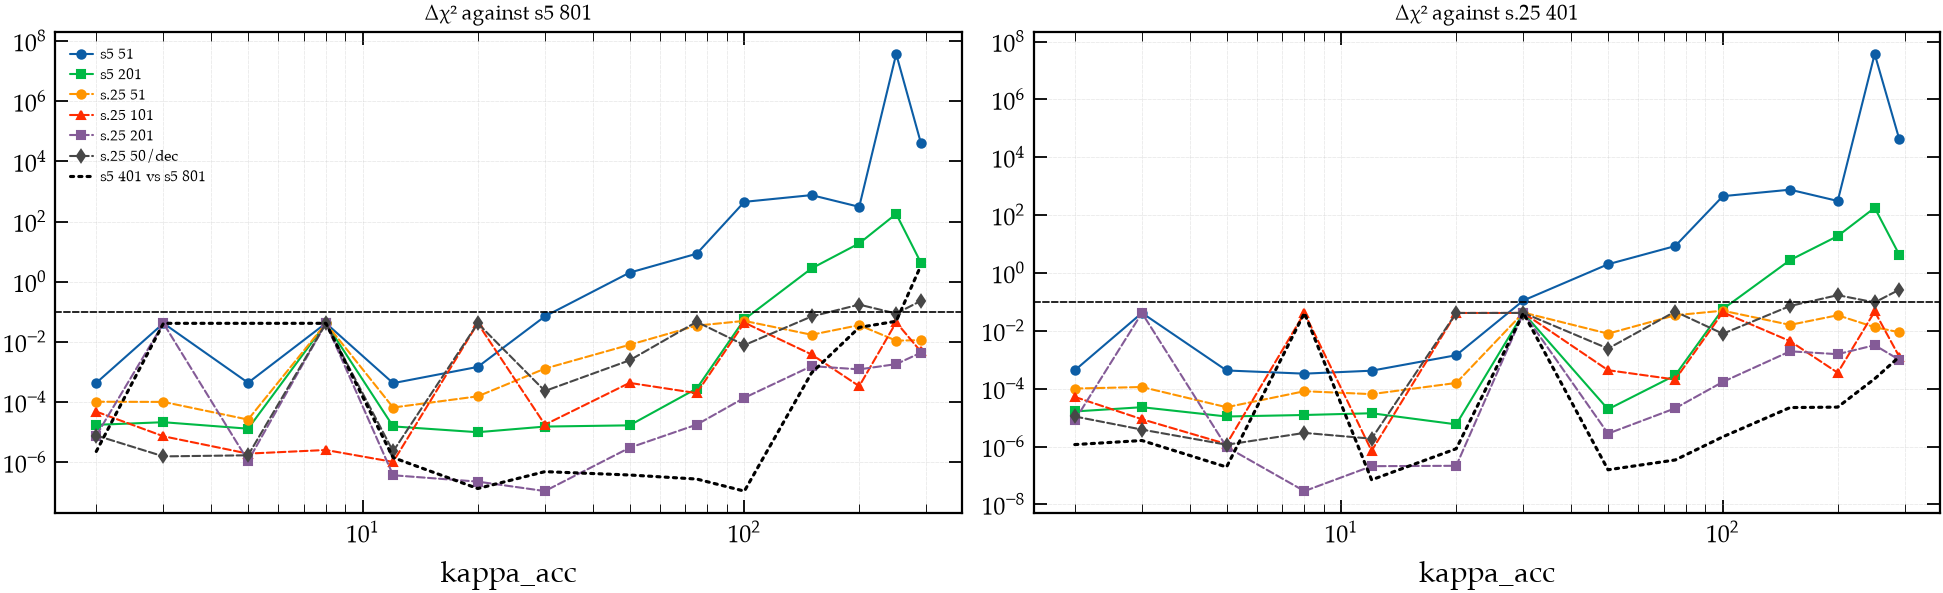

In [6]:
rows = []
for k in KAPPAS:
    row = {'kappa': k}
    for lab, base in [('s5 51', REF), ('s.25 51', REF), ('s.25 51', ALT_REF), ('s.25 101', ALT_REF),
                      ('s.25 201', ALT_REF), ('s.25 50/dec', ALT_REF), (REF_CHECK, REF), (REF, ALT_REF)]:
        c = compare(lab, k, base=base)
        row['{} vs {}'.format(lab, base)] = np.nan if c is None else c['dchi2']
    row['signal (801 vs null)'] = chi2_parts(res[(REF, k)], null)['total'] if ok(res[(REF, k)]) else np.nan
    rows.append(row)
dtab = pd.DataFrame(rows).set_index('kappa')
display(dtab.apply(lambda col: col.map(lambda v: '-' if pd.isna(v) else '{:.1e}'.format(v))))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for lab, st in [('s5 51', 'o-'), ('s5 201', 's-'), ('s.25 51', 'o--'), ('s.25 101', '^--'), ('s.25 201', 's--'),
                ('s.25 50/dec', 'd--')]:
    for ax, base in zip(axes, (REF, ALT_REF)):
        pts = [(k, compare(lab, k, base=base)) for k in KAPPAS]
        pts = [(k, max(c['dchi2'], 1e-12)) for k, c in pts if c is not None]
        if pts:
            ax.loglog(*zip(*pts), st, ms=4, lw=1, label=lab)
for ax, base in zip(axes, (REF, ALT_REF)):
    pts = [(k, compare(REF_CHECK if base == REF else REF, k, base=base)) for k in KAPPAS]
    pts = [(k, max(c['dchi2'], 1e-12)) for k, c in pts if c is not None]
    ax.loglog(*zip(*pts), 'k:', lw=1.5, label='{} vs {}'.format(REF_CHECK if base == REF else REF, base))
    ax.axhline(DCHI2_TOL, color='k', ls='--', lw=0.8)
    ax.set_title('Δχ² against {}'.format(base), fontsize=10)
    ax.set_xlabel('kappa_acc')
    ax.grid(alpha=0.3, which='both')
axes[0].legend(fontsize=7)
plt.show()

## Reading the result

- **Section 0:** with s = 0.25, 37–43 of 51 nodes sit inside the births at every κ. The even grid keeps 23 at
  κ = 2 and drops to a single node from κ = 150.
- **References:** the two references agree. The even grid at 801 bins and s = 0.25 at 401 bins differ by Δχ² ≤ 1.3e-3
  and max |ΔP_cb/P_cb| ≤ 1.3e-3 at every κ, apart from two 0.041 jumps (κ = 8, 30). So the new grid converges to
  the same answer. At large κ, s = 0.25 at 401 is the better reference: the even grid's 401 vs 801 reaches
  Δχ² = 3.4 at κ = 290.
- **Δχ²:** s = 0.25 with 51 bins stays at Δχ² ≤ 0.05 against both references at every κ up to 290. With the same
  51 bins, the even grid exceeds 0.1 from κ = 50 and reaches 450 at κ = 100 and 4e7 at κ = 250. On Δχ² alone,
  the 51-bin born-fraction grid covers more than nb33's 401-bin even grid did.
- **P_cb (nb33's 1e-3 tolerance):** s = 0.25 is stable up to κ = 50 at 51 bins (even grid: 30), 75 at 101 (even:
  30) and 100 at 201 (even: 75). Beyond that its error is 1–6.5e-3 at 51 bins, against 0.09–49 for the even grid.
  Above κ ≈ 100 the remaining error is a near-constant offset across k. It shrinks only slowly with bins (κ = 150:
  4.4, 2.4, 1.6e-3 at 51, 101, 201) and changes sign, which does not look like a lack of nodes in the window. At
  κ ≥ 250 the two references differ by 0.5–1.3e-3, so the 1e-3 tolerance is at the edge of what is resolvable.
- **The 50/decade default count with s = 0.25** (55 nodes at large κ, since a_min rises with κ) does worse at
  κ ≥ 150 than 51 explicit bins: Δχ² 0.07–0.26 against ≤ 0.04. The large-κ error varies non-monotonically
  with node count; the cause is not established here.
- **Floor:** the Δχ² ≈ 0.041 jumps show up again (κ = 3, 8, 20, 30, …) for both grids and all node counts.
- **Never worse:** at small κ, s = 0.25 is at least as good as the even grid (κ ≤ 12: Δχ² 2e-5–1e-4 against
  4e-4).

**Verdict:** s = 0.25 holds up across κ. It extends the 51-bin Δχ²-stable range from κ = 30 to the full range
up to the overflow limit, and cuts the large-κ P_cb error by 1–4 orders of magnitude. With the chain settings
(nb38, κ = 12.1) this supports making it the default. Open points:
1. the ~1e-3 P_cb offset above κ ≈ 100 (201 bins needed for 1e-3 there);
2. the non-monotonic node-count dependence at κ ≥ 150;
3. the 0.04 jumps.